## Plotting and Metrics

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import plot_utils as pu

import sys
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.data_prep import load_run_data, build_global_init_map, build_run_trajectory, build_neighbors_index, _numeric_agent_key, build_row_normalized_adjacency
from models.analysis_utils import (
    evaluate_validation_model,
    align_rollout_pair,
    plot_mean_per_timestep,
    plot_variance_per_timestep,
    plot_wasserstein_distance_per_timestep,
    plot_observed_trajectories,
    plot_predicted_vs_observed,
    plot_box_per_timestep,
    plot_violin_per_timestep,
    compute_mean_prediction_error,
    compute_max_prediction_error,
)
from models.adjacency_based.degroot import (
    fit_degroot_adjacency_scalar,
    degroot_rollout_prediction,
)
from models.adjacency_based.friedkin_johnsen import (
    fit_base_friedkin_johnson_adjency,
    base_friedkin_johnsen_adjacency_rollout,
    select_base_friedkin_johnsen_adjacency_lambda,
    fit_friedkin_johnsen_adjacency,
    select_friedkin_johnsen_adjacency_lambdas,
    friedkin_johnsen_adjacency_rollout,
)
from models.adjacency_based.homophily import (
    fit_homophily,
    rollout_with_homophily,
    fit_homophily_stubborness,
    rollout_with_homophily_stubborness,
    fit_homophily_friedkin_johnsen,
    rollout_with_homophily_friedkin_johnsen,
)

from models.fixed_graph.degroot import fit_row_stochastic_W_from_pooled_runs, degroot_rollout_prediction as fixed_graph_degroot_rollout_prediction
from models.fixed_graph.friedkin_johnsen import (
    select_friedkin_johnsen_lambdas,
    fit_friedkin_johnsen,
    friedkin_johnsen_rollout_prediction,
)
from models.fixed_graph.homophily import (
    fit_fg_homophily,
    rollout_fg_homophily,
    fit_fg_fj_homophily,
    rollout_fg_fj_homophily,
    fit_fg_fj_bias_homophily,
    rollout_fg_fj_bias_homophily,
)


### Fixed Graph vs Adjacency Based

### Componenets of Adjacency Based

In [2]:
# Set the LLM and topic
ROOT = Path('.').resolve()
LLM_NAME = 'llama3.1'
TOPIC_NAME = 'climate'
SPLIT_NAME = 'train'
RUNS_ROOT = ROOT / 'runs' / LLM_NAME / TOPIC_NAME / SPLIT_NAME
train_path = RUNS_ROOT

PARAMS = {
    'target_agent_fraction': 0.4,
    'constrain_messages': 150,
    'rollout_horizon_cap': 20,
    'sample_plot_horizon': 15,
}

print('Project root:', ROOT)
print('Runs root:', RUNS_ROOT)
print('Configured LLM/topic/split:', LLM_NAME, TOPIC_NAME, SPLIT_NAME)

RUN_DIRS = sorted([p for p in RUNS_ROOT.iterdir() if p.is_dir()])
print('Runs found:', len(RUN_DIRS))
for run_dir in RUN_DIRS[:20]:
    print(' ', run_dir.name)

RUN_DATA = {run_dir.name: load_run_data(run_dir) for run_dir in RUN_DIRS}
GLOBAL_AGENT_IDS = sorted({agent for data in RUN_DATA.values() for agent in data['agent_ids']}, key=_numeric_agent_key)
N_AGENTS = len(GLOBAL_AGENT_IDS)
GLOBAL_INIT_BY_AGENT = build_global_init_map(RUN_DATA, GLOBAL_AGENT_IDS)
RUN_TRAJ_AND_MASK = {
    run_name: build_run_trajectory(
        data,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for run_name, data in RUN_DATA.items()
}
RUN_TRAJ = {run_name: traj_mask[0] for run_name, traj_mask in RUN_TRAJ_AND_MASK.items()}
RUN_POST_MASK = {run_name: traj_mask[1] for run_name, traj_mask in RUN_TRAJ_AND_MASK.items()}
RUN_NEIGHBORS = {run_name: build_neighbors_index(data, GLOBAL_AGENT_IDS) for run_name, data in RUN_DATA.items()}

print('Global agent count:', N_AGENTS)
print('Global init priors available:', len(GLOBAL_INIT_BY_AGENT))
for run_name in sorted(RUN_TRAJ.keys()):
    traj = np.asarray(RUN_TRAJ[run_name], dtype=float)
    print(f'{run_name}: trajectory shape={traj.shape}, horizon={traj.shape[0] - 1}')



Project root: /Users/samuelli/Documents/code/llm/llm-network/modeling
Runs root: /Users/samuelli/Documents/code/llm/llm-network/modeling/runs/llama3.1/climate/train
Configured LLM/topic/split: llama3.1 climate train
Runs found: 24
  run_20260506-223938
  run_20260506-225959
  run_20260506-232018
  run_20260506-234038
  run_20260507-000056
  run_20260507-002116
  run_20260507-004135
  run_20260507-010156
  run_20260507-012214
  run_20260507-014232
  run_20260507-020250
  run_20260507-022306
  run_20260507-024322
  run_20260507-030339
  run_20260507-032355
  run_20260507-034414
  run_20260507-040436
  run_20260507-042451
  run_20260507-044507
  run_20260507-050523
Global agent count: 30
Global init priors available: 30
run_20260506-223938: trajectory shape=(11, 30), horizon=10
run_20260506-225959: trajectory shape=(12, 30), horizon=11
run_20260506-232018: trajectory shape=(12, 30), horizon=11
run_20260506-234038: trajectory shape=(12, 30), horizon=11
run_20260507-000056: trajectory shape

In [ ]:
DEGROOT_ADJ = fit_degroot_adjacency_scalar(RUN_TRAJ, RUN_NEIGHBORS)
GLOBAL_W = DEGROOT_ADJ['W_blocks']
DEGROOT_GAMMA = DEGROOT_ADJ['gamma']
DEGROOT_POOL_MSE = DEGROOT_ADJ['mse_pool']

LAMBDA_GRID = np.linspace(0.0, 1.0, 50)

BEST_BASE_FJ_ADJ, BASE_FJ_ADJ_GRID = select_base_friedkin_johnsen_adjacency_lambda(RUN_TRAJ, RUN_NEIGHBORS, LAMBDA_GRID)
BASE_FJ_ADJ_L1 = BEST_BASE_FJ_ADJ['lambda1']
BASE_FJ_ADJ_FIT = fit_base_friedkin_johnson_adjency(RUN_TRAJ, RUN_NEIGHBORS, BASE_FJ_ADJ_L1)
BASE_FJ_ADJ_GAMMA = BASE_FJ_ADJ_FIT['gamma']
BASE_FJ_ADJ_W = BASE_FJ_ADJ_FIT['W_blocks']
BASE_FJ_ADJ_POOL_MSE = BASE_FJ_ADJ_FIT['mse_pool']

BEST_FJ_ADJ, FJ_ADJ_GRID = select_friedkin_johnsen_adjacency_lambdas(RUN_TRAJ, RUN_NEIGHBORS, LAMBDA_GRID)
FJ_ADJ_L1 = BEST_FJ_ADJ['lambda1']
FJ_ADJ_L2 = BEST_FJ_ADJ['lambda2']
FJ_ADJ_FIT = fit_friedkin_johnsen_adjacency(RUN_TRAJ, RUN_NEIGHBORS, FJ_ADJ_L1, FJ_ADJ_L2)
FJ_ADJ_GAMMA = FJ_ADJ_FIT['gamma']
FJ_ADJ_BIAS = FJ_ADJ_FIT['bias']
FJ_ADJ_W = FJ_ADJ_FIT['W_blocks']
FJ_ADJ_POOL_MSE = FJ_ADJ_FIT['mse_pool']

HOMOPHILY = fit_homophily(RUN_TRAJ, RUN_NEIGHBORS, gamma0=1.0)
HOMOPHILY_A = HOMOPHILY['Abar_blocks']
HOMOPHILY_GAMMA = HOMOPHILY['gamma']
HOMOPHILY_LAMBDA = HOMOPHILY['lambda']

BEST_HOMO_FJ = fit_homophily_friedkin_johnsen(RUN_TRAJ, RUN_NEIGHBORS, gamma0=HOMOPHILY_GAMMA)
HOMO_FJ_A = BEST_HOMO_FJ['Abar_blocks']
HOMO_FJ_GAMMA = BEST_HOMO_FJ['gamma']
HOMO_FJ_L1 = BEST_HOMO_FJ['lambda1']
HOMO_FJ_LSELF = BEST_HOMO_FJ['lambda_self']

BEST_HOMO_STUB = fit_homophily_stubborness(RUN_TRAJ, RUN_NEIGHBORS, gamma0=HOMOPHILY_GAMMA)
HOMO_STUB_A = BEST_HOMO_STUB['Abar_blocks']
HOMO_STUB_GAMMA = BEST_HOMO_STUB['gamma']
HOMO_STUB_BIAS = BEST_HOMO_STUB['bias']
HOMO_STUB_L1 = BEST_HOMO_STUB['lambda1']
HOMO_STUB_L2 = BEST_HOMO_STUB['lambda2']
HOMO_STUB_LSELF = BEST_HOMO_STUB['lambda_self']

print('Adjacency fit summary')
print('  DeGroot gamma:', DEGROOT_GAMMA)
print('  DeGroot pooled MSE:', DEGROOT_POOL_MSE)
print('  Base FJ (no bias) lambda1:', BASE_FJ_ADJ_L1)
print('  Base FJ (no bias) gamma:', BASE_FJ_ADJ_GAMMA)
print('  Base FJ (no bias) pooled MSE:', BASE_FJ_ADJ_POOL_MSE)
print('  FJ adjacency lambdas:', (FJ_ADJ_L1, FJ_ADJ_L2))
print('  FJ adjacency gamma:', FJ_ADJ_GAMMA)
print('  FJ adjacency bias:', FJ_ADJ_BIAS)
print('  FJ adjacency pooled MSE:', FJ_ADJ_POOL_MSE)
print('  Homophily lambda:', HOMOPHILY_LAMBDA)
print('  Homophily gamma:', HOMOPHILY_GAMMA)
print('  Homophily pooled MSE:', HOMOPHILY['mse_pool'])
print('  Homophily FJ pooled MSE:', BEST_HOMO_FJ['mse_pool'])
print('  Homophily stubbornness pooled MSE:', BEST_HOMO_STUB['mse_pool'])

# Load test split and build test trajectories/neighbors
TEST_RUNS_ROOT = ROOT / 'runs' / LLM_NAME / TOPIC_NAME / 'test'
TEST_RUN_DIRS = sorted([p for p in TEST_RUNS_ROOT.iterdir() if p.is_dir()])
TEST_RUN_DATA = {run_dir.name: load_run_data(run_dir) for run_dir in TEST_RUN_DIRS}
TEST_RUN_TRAJ_AND_MASK = {
    run_name: build_run_trajectory(
        data,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for run_name, data in TEST_RUN_DATA.items()
}
TEST_RUN_TRAJ = {run_name: traj_mask[0] for run_name, traj_mask in TEST_RUN_TRAJ_AND_MASK.items()}
TEST_RUN_NEIGHBORS = {run_name: build_neighbors_index(data, GLOBAL_AGENT_IDS) for run_name, data in TEST_RUN_DATA.items()}

# Build test-time adjacency/weight maps using the fitted parameters from training
TEST_DEGROOT_W = {
    rn: DEGROOT_GAMMA * build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N_AGENTS)
    + (1.0 - DEGROOT_GAMMA) * np.eye(N_AGENTS, dtype=float)
    for rn in TEST_RUN_TRAJ.keys()
}

TEST_BASE_FJ_ADJ_W = {
    rn: BASE_FJ_ADJ_GAMMA * build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N_AGENTS)
    + (1.0 - BASE_FJ_ADJ_GAMMA) * np.eye(N_AGENTS, dtype=float)
    for rn in TEST_RUN_TRAJ.keys()
}

TEST_FJ_ADJ_W = {
    rn: FJ_ADJ_GAMMA * build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N_AGENTS)
    + (1.0 - FJ_ADJ_GAMMA) * np.eye(N_AGENTS, dtype=float)
    for rn in TEST_RUN_TRAJ.keys()
}

TEST_HOMOPHILY_A = {rn: build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N_AGENTS) for rn in TEST_RUN_TRAJ.keys()}
TEST_HOMO_FJ_A = {rn: build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N_AGENTS) for rn in TEST_RUN_TRAJ.keys()}
TEST_HOMO_STUB_A = {rn: build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N_AGENTS) for rn in TEST_RUN_TRAJ.keys()}

# Create rollout maps for test runs (evaluate on test only)
MODEL_RESULTS = {}
ROLLOUT_MAPS = {
    'degroot_adjacency_scalar': {
        run_name: degroot_rollout_prediction(
            TEST_DEGROOT_W[run_name],
            np.asarray(TEST_RUN_TRAJ[run_name], dtype=float)[0],
            PARAMS['rollout_horizon_cap'],
        )
        for run_name in TEST_RUN_TRAJ.keys()
    },
    'fj_adjacency_no_bias': {
        run_name: base_friedkin_johnsen_adjacency_rollout(
            TEST_BASE_FJ_ADJ_W[run_name],
            np.asarray(TEST_RUN_TRAJ[run_name], dtype=float)[0],
            PARAMS['rollout_horizon_cap'],
            BASE_FJ_ADJ_L1,
        )
        for run_name in TEST_RUN_TRAJ.keys()
    },
    'fj_adjacency': {
        run_name: friedkin_johnsen_adjacency_rollout(
            TEST_FJ_ADJ_W[run_name],
            FJ_ADJ_BIAS,
            np.asarray(TEST_RUN_TRAJ[run_name], dtype=float)[0],
            PARAMS['rollout_horizon_cap'],
            FJ_ADJ_L1,
            FJ_ADJ_L2,
        )
        for run_name in TEST_RUN_TRAJ.keys()
    },
    'homophily': {
        run_name: rollout_with_homophily(
            TEST_HOMOPHILY_A[run_name],
            HOMOPHILY_GAMMA,
            np.asarray(TEST_RUN_TRAJ[run_name], dtype=float)[0],
            PARAMS['rollout_horizon_cap'],
            lambda_self=HOMOPHILY_LAMBDA,
        )
        for run_name in TEST_RUN_TRAJ.keys()
    },
    'homophily_friedkin_johnsen': {
        run_name: rollout_with_homophily_friedkin_johnsen(
            TEST_HOMO_FJ_A[run_name],
            HOMO_FJ_GAMMA,
            HOMO_FJ_L1,
            np.asarray(TEST_RUN_TRAJ[run_name], dtype=float)[0],
            PARAMS['rollout_horizon_cap'],
            lambda_self=HOMO_FJ_LSELF,
        )
        for run_name in TEST_RUN_TRAJ.keys()
    },
    'homophily_stubbornness': {
        run_name: rollout_with_homophily_stubborness(
            TEST_HOMO_STUB_A[run_name],
            HOMO_STUB_GAMMA,
            HOMO_STUB_BIAS,
            HOMO_STUB_L1,
            HOMO_STUB_L2,
            np.asarray(TEST_RUN_TRAJ[run_name], dtype=float)[0],
            PARAMS['rollout_horizon_cap'],
            lambda_self=HOMO_STUB_LSELF,
        )
        for run_name in TEST_RUN_TRAJ.keys()
    },
}


Adjacency fit summary
  DeGroot gamma: 0.08118255322668783
  DeGroot pooled MSE: 0.026393661844907358
  Base FJ (no bias) lambda1: 0.0
  Base FJ (no bias) gamma: 0.08118255322668783
  Base FJ (no bias) pooled MSE: 0.026393661844907358
  FJ adjacency lambdas: (0.020100502512562814, 0.32663316582914576)
  FJ adjacency gamma: 0.004373435344246679
  FJ adjacency bias: 0.6721072229564765
  FJ adjacency pooled MSE: 0.019656404077179654
  Homophily lambda: 0.6572682193593643
  Homophily gamma: 1.4487032306876617
  Homophily pooled MSE: 0.022050590837474883
  Homophily FJ pooled MSE: 0.02204419575651433
  Homophily stubbornness pooled MSE: 0.019655266106255863


In [4]:
def stack_curves(curves):
    curves = [np.asarray(curve, dtype=float).ravel() for curve in curves if len(curve) > 0]
    if not curves:
        return np.empty((0, 0), dtype=float)
    common_t = min(curve.shape[0] for curve in curves)
    return np.stack([curve[:common_t] for curve in curves], axis=0)


def evaluate_model(model_name, run_traj_map, rollout_map):
    per_run_rows = []
    observed_curves = []
    predicted_curves = []
    mean_true_curves = []
    mean_pred_curves = []
    var_true_curves = []
    var_pred_curves = []
    wasserstein_curves = []

    for run_name in sorted(run_traj_map.keys()):
        observed = np.asarray(run_traj_map[run_name], dtype=float)
        predicted = np.asarray(rollout_map[run_name], dtype=float)
        t_common = min(observed.shape[0], predicted.shape[0])
        observed = observed[:t_common]
        predicted = predicted[:t_common]

        mean_true = np.mean(observed, axis=1)
        mean_pred = np.mean(predicted, axis=1)
        var_true = np.var(observed, axis=1)
        var_pred = np.var(predicted, axis=1)
        wasserstein = pu.compute_wasserstein_distance_per_timestep(observed, predicted)
        mean_error = np.abs(mean_pred - mean_true)
        var_error = np.abs(var_pred - var_true)

        per_run_rows.append({
            'model': model_name,
            'run_name': run_name,
            'run_length': int(t_common - 1),
            'run_max_wasserstein': float(np.max(wasserstein)) if wasserstein.size else np.nan,
            'run_integral_wasserstein': float(np.sum(wasserstein)) if wasserstein.size else np.nan,
            'run_max_mean_error': float(np.max(mean_error)) if mean_error.size else np.nan,
            'run_integral_mean_error': float(np.sum(mean_error)) if mean_error.size else np.nan,
            'run_max_variance_error': float(np.max(var_error)) if var_error.size else np.nan,
            'run_integral_variance_error': float(np.sum(var_error)) if var_error.size else np.nan,
            'transition_mse': float(np.mean((observed - predicted) ** 2)),
        })

        observed_curves.append(observed)
        predicted_curves.append(predicted)
        mean_true_curves.append(mean_true)
        mean_pred_curves.append(mean_pred)
        var_true_curves.append(var_true)
        var_pred_curves.append(var_pred)
        wasserstein_curves.append(wasserstein)

    per_run = pd.DataFrame(per_run_rows)
    summary = {
        'model': model_name,
        'n_runs': int(per_run.shape[0]),
        'run_max_wasserstein_mean': float(per_run['run_max_wasserstein'].mean()),
        'run_integral_wasserstein_mean': float(per_run['run_integral_wasserstein'].mean()),
        'run_max_mean_error_mean': float(per_run['run_max_mean_error'].mean()),
        'run_integral_mean_error_mean': float(per_run['run_integral_mean_error'].mean()),
        'run_max_variance_error_mean': float(per_run['run_max_variance_error'].mean()),
        'run_integral_variance_error_mean': float(per_run['run_integral_variance_error'].mean()),
        'transition_mse_mean': float(per_run['transition_mse'].mean()),
    }

    return {
        'per_run': per_run,
        'summary': summary,
        'observed_stack': stack_curves(observed_curves),
        'predicted_stack': stack_curves(predicted_curves),
        'mean_true_stack': stack_curves(mean_true_curves),
        'mean_pred_stack': stack_curves(mean_pred_curves),
        'var_true_stack': stack_curves(var_true_curves),
        'var_pred_stack': stack_curves(var_pred_curves),
        'wasserstein_stack': stack_curves(wasserstein_curves),
    }


Model ranking by average run-integral Wasserstein:
                        model  n_runs  run_max_wasserstein_mean  \
0      homophily_stubbornness       8                  0.107720   
1                fj_adjacency       8                  0.108173   
2    degroot_adjacency_scalar       8                  0.244962   
3        fj_adjacency_no_bias       8                  0.244962   
4  homophily_friedkin_johnsen       8                  0.228704   
5                   homophily       8                  0.228661   

   run_integral_wasserstein_mean  run_max_mean_error_mean  \
0                       0.869203                 0.059690   
1                       0.869702                 0.060766   
2                       2.057534                 0.242453   
3                       2.057534                 0.242453   
4                       2.058558                 0.207524   
5                       2.064550                 0.206874   

   run_integral_mean_error_mean  run_max_variance_

/Users/samuelli/Documents/code/llm/llm-network/modeling/plot_utils.py:213: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
/Users/samuelli/Documents/code/llm/llm-network/venv/lib/python3.11/site-packages/IPython/core/events.py:96: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  func(*args, **kwargs)


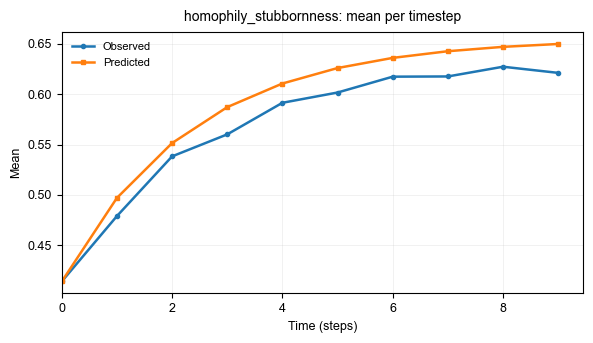

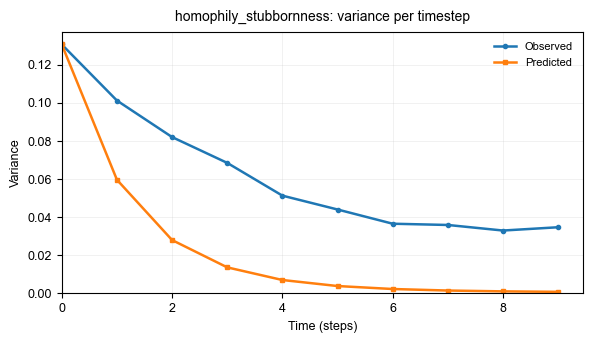

/Users/samuelli/Documents/code/llm/llm-network/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


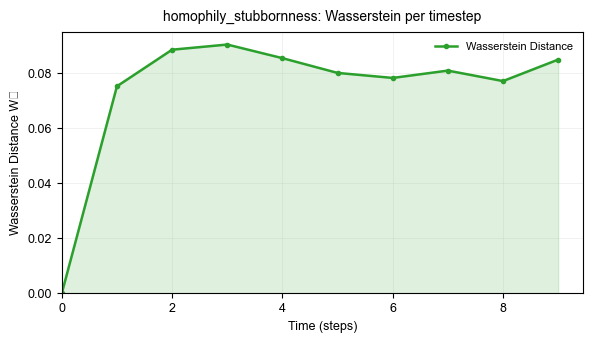

In [5]:
MODEL_RESULTS = {model_name: evaluate_model(model_name, TEST_RUN_TRAJ, rollout_map) for model_name, rollout_map in ROLLOUT_MAPS.items()}
PER_RUN_METRICS = pd.concat([result['per_run'] for result in MODEL_RESULTS.values()], ignore_index=True)
MODEL_SUMMARY = pd.DataFrame([result['summary'] for result in MODEL_RESULTS.values()]).sort_values('run_integral_wasserstein_mean').reset_index(drop=True)
BEST_MODEL = MODEL_SUMMARY.iloc[0]['model']
BEST_MODEL_RESULT = MODEL_RESULTS[BEST_MODEL]
BEST_BY_RUN = PER_RUN_METRICS.sort_values('run_integral_wasserstein').groupby('run_name', as_index=False).first()

print('\nModel ranking by average run-integral Wasserstein:')
print(MODEL_SUMMARY)
print('\nBest model per run:')
print(BEST_BY_RUN[['run_name', 'model', 'run_integral_wasserstein', 'run_max_wasserstein']])

if BEST_MODEL_RESULT['mean_true_stack'].size:
    shared_horizon = min(
        BEST_MODEL_RESULT['mean_true_stack'].shape[1],
        BEST_MODEL_RESULT['mean_pred_stack'].shape[1],
        BEST_MODEL_RESULT['var_true_stack'].shape[1],
        BEST_MODEL_RESULT['var_pred_stack'].shape[1],
        BEST_MODEL_RESULT['wasserstein_stack'].shape[1],
    )
    pu.plot_mean_per_timestep(
        BEST_MODEL_RESULT['mean_true_stack'].mean(axis=0)[:shared_horizon],
        BEST_MODEL_RESULT['mean_pred_stack'].mean(axis=0)[:shared_horizon],
        title=f'{BEST_MODEL}: mean per timestep',
    )
    pu.plot_variance_per_timestep(
        BEST_MODEL_RESULT['var_true_stack'].mean(axis=0)[:shared_horizon],
        BEST_MODEL_RESULT['var_pred_stack'].mean(axis=0)[:shared_horizon],
        title=f'{BEST_MODEL}: variance per timestep',
    )
    pu.plot_wasserstein_distance_per_timestep(
        BEST_MODEL_RESULT['wasserstein_stack'].mean(axis=0)[:shared_horizon],
        title=f'{BEST_MODEL}: Wasserstein per timestep',
    )



Sample run for detailed plots: run_20260507-080811
Sample plot horizon: 12


(<Figure size 1000x350 with 1 Axes>,
 <Axes: title={'center': 'run_20260507-080811: distributions per timestep (homophily_stubbornness)'}, xlabel='Time (steps)', ylabel='Value'>)

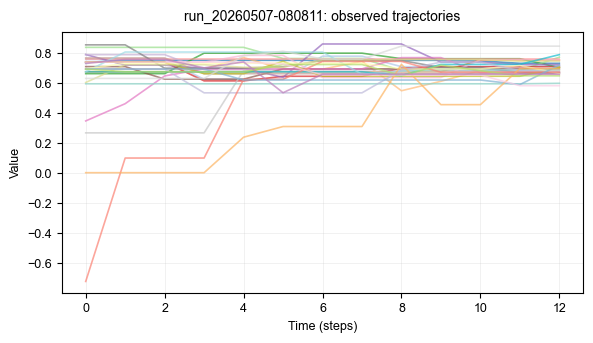

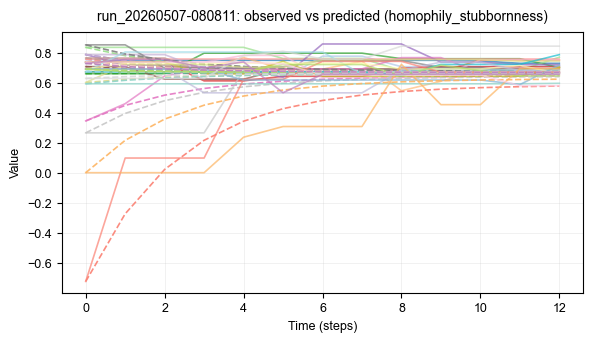

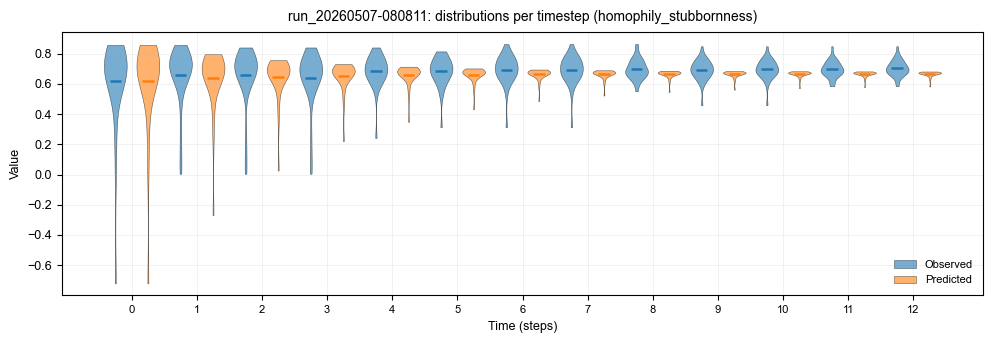

In [6]:
SAMPLE_RUN = max(TEST_RUN_TRAJ, key=lambda run_name: np.asarray(TEST_RUN_TRAJ[run_name], dtype=float).shape[0])
SAMPLE_OBS = np.asarray(TEST_RUN_TRAJ[SAMPLE_RUN], dtype=float)
SAMPLE_PRED = np.asarray(ROLLOUT_MAPS[BEST_MODEL][SAMPLE_RUN], dtype=float)
t_common = min(SAMPLE_OBS.shape[0], SAMPLE_PRED.shape[0])
SAMPLE_OBS = SAMPLE_OBS[:t_common]
SAMPLE_PRED = SAMPLE_PRED[:t_common]
SAMPLE_PLOT_HORIZON = min(
    PARAMS['sample_plot_horizon'],
    SAMPLE_OBS.shape[0] - 1,
    SAMPLE_PRED.shape[0] - 1,
)

print('\nSample run for detailed plots:', SAMPLE_RUN)
print('Sample plot horizon:', SAMPLE_PLOT_HORIZON)
pu.plot_observed_trajectories(
    SAMPLE_OBS,
    title=f'{SAMPLE_RUN}: observed trajectories',
    horizon=SAMPLE_PLOT_HORIZON,
)
pu.plot_predicted_vs_observed(
    SAMPLE_OBS,
    SAMPLE_PRED,
    title=f'{SAMPLE_RUN}: observed vs predicted ({BEST_MODEL})',
    horizon=SAMPLE_PLOT_HORIZON,
)
pu.plot_violin_per_timestep(
    SAMPLE_OBS[: SAMPLE_PLOT_HORIZON + 1],
    SAMPLE_PRED[: SAMPLE_PLOT_HORIZON + 1],
    title=f'{SAMPLE_RUN}: distributions per timestep ({BEST_MODEL})',
)


### Across LLMs and Topics